# ICS 604: APPLIED DATA SCIENCE 

## Correlations
---

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

## Correlations

When we collect $n$ observations from two random variables $X$ and $Y$, we are often interested in understanding whether a relationship exists between them. We say that $X$ and $Y$ are *correlated* if knowing the value of one variable helps us better predict the value of the other. This relationship is summarized by the **correlation coefficient**, a numerical measure that captures both the strength and direction of the association. A positive correlation means that as one variable increases, the other tends to increase, while a negative correlation indicates that as one increases, the other tends to decrease. The closer the coefficient is to 1 or −1, the stronger the relationship; values near 0 suggest little to no linear association.

Real-world examples help illustrate these ideas. For instance, weight and height typically show a relatively strong positive correlation, since taller individuals often weigh more. Similarly, the number of tourists in Waikiki is positively associated with total sales at ABC stores, as increased visitor volume tends to drive higher retail activity. On the other hand, some relationships are negative: higher IQ may be associated with less time needed to solve simple logic problems, and greater daily cigarette consumption is linked to fewer years lived. Not all correlations are strong or reliable, however; for example, the relationship between video game usage and violent behavior scores is often found to be very weak and difficult to reproduce consistently. These examples highlight both the usefulness and the limitations of correlation in understanding relationships between variables.

### Linear Correlations

Linear correlation describes the strength and direction of a linear relationship between two variables. Its value ranges from −1 to 1. A correlation of 1 indicates a perfect positive linear relationship, meaning that as one variable increases, the other increases in a perfectly predictable way. A value of −1 represents a perfect negative (or anti-) correlation, where one variable increases exactly as the other decreases. A correlation near 0 suggests that there is no linear relationship between the variables, although other types of (nonlinear) relationships may still exist.

There are several methods used to compute linear correlation, with the most widely used being **Pearson’s Correlation Coefficient** ($R$) and **Spearman’s Rank Correlation** ($\rho$). Pearson’s coefficient measures the strength of a linear relationship based directly on the numerical values of the data, making it sensitive to outliers and best suited for normally distributed variables. In contrast, Spearman’s rank correlation is based on the relative ordering (ranks) of the data rather than their raw values, making it more robust to outliers and better suited for monotonic relationships that may not be strictly linear. Together, these measures provide flexible tools for assessing associations in different types of data.

### Positive Correlation and Deviation from the Means

A useful way to understand positive correlation is through deviations from the mean. Consider the deterministic relationship $Y = X + 10$, where each value of $Y$ is exactly 10 units greater than the corresponding value of $X$. If we compute the means of $X$ and $Y$, we will find that both variables increase together in a perfectly consistent way. For every observation $i$, when $X_i$ is above its mean, $Y_i$ is also above its mean; similarly, when $X_i$ is below its mean, $Y_i$ is also below its mean. This aligned movement in deviations is the hallmark of a positive correlation.
 
<center><img src="https://www.dropbox.com/scl/fi/jwofph8pintqtursn2jm5/correlation_distance_mean.png?rlkey=yhs6lz1nyyr5u9wkx33z39mdo&st=8k1jhokw&dl=1" alt="drawing" width="500"></center>
<br>
In the dataset shown, $X = [1, 2, …, 10]$ and $Y = [11, 12, …, 20]$, both variables increase steadily. Because the relationship is perfectly linear and deterministic, the correlation between $X$ and $Y$ is 1, indicating a perfect positive linear correlation. This example clearly illustrates that when two variables move together in the same direction — and their deviations from their respective means consistently match in sign — their correlation is strongly positive.

In [2]:
# Example of a deterministic relationship: Y = X + 10

X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y = [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

data = pd.DataFrame({"X": X, "Y": Y})
data

,X,Y
0,1,11
1,2,12
2,3,13
3,4,14
4,5,15
5,6,16
6,7,17
7,8,18
8,9,19
9,10,20


In [3]:
print(data["X"].mean(), data["Y"].mean())

5.5 15.5


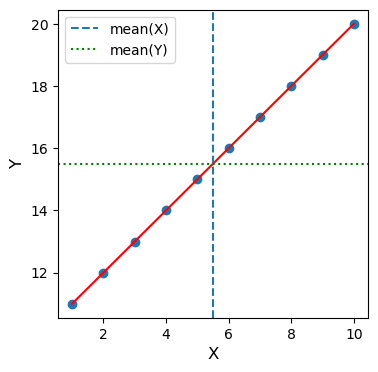

In [4]:
plt.figure(figsize=(4, 4))

plt.scatter(X, Y)
plt.plot(X, Y, color='r')

plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.axvline(data["X"].mean(), linestyle='--', label="mean(X)")
plt.axhline(data["Y"].mean(), linestyle=':', label="mean(Y)", color='green')
plt.legend();

### Negative Correlation and Deviation from the Means

Negative correlation can also be understood by examining how variables deviate from their means. In this example, as $X$ increases from 1 to 10, $Y$ decreases from 10 to 1. If we compute the mean of each variable, we observe that whenever $X_i$ is above its mean, $Y_i$ is below its mean, and vice versa. In other words, the deviations from the mean move in opposite directions. This opposite alignment of deviations is the defining characteristic of a negative correlation.
 
<center><img src="https://www.dropbox.com/scl/fi/ld3ld51ia2gdvo5jhho4z/neg_corr_dist.png?rlkey=e766afuyg61lk441zih910rjt&st=3bax1nrx&dl=1" alt="drawing" width="550"></center>
<br>

Because the relationship between $X$ and $Y$ is perfectly linear and decreasing, it represents a perfect negative correlation with a coefficient of −1. This means that knowing the value of $X$ allows us to predict $Y$ exactly, but in an inverse manner. This example highlights that when one variable consistently increases while the other decreases — and their deviations from their means always have opposite signs — the variables are strongly negatively correlated.

In [5]:
X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

data = pd.DataFrame({"X": X, "Y": Y})
data

,X,Y
0,1,10
1,2,9
2,3,8
3,4,7
4,5,6
5,6,5
6,7,4
7,8,3
8,9,2
9,10,1


In [6]:
print(data["X"].mean(), data["Y"].mean())

5.5 5.5


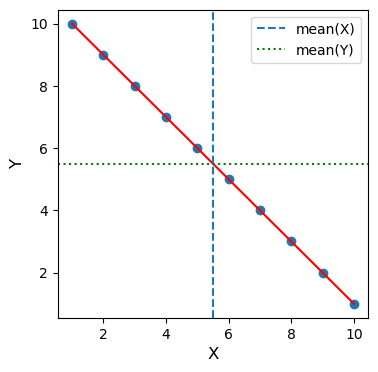

In [7]:
plt.figure(figsize=(4, 4))

plt.scatter(X, Y)
plt.plot(X, Y, color='r')

plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.axvline(data["X"].mean(), linestyle='--', label="mean(X)")
plt.axhline(data["Y"].mean(), linestyle=':', label="mean(Y)", color='green')
plt.legend();

### Lack of Correlation and Deviation from the Means

A lack of correlation occurs when there is no consistent relationship between how two variables move relative to their means. In this example, while $X$ increases steadily from 1 to 9, the values of $Y$ fluctuate irregularly without a clear pattern. When we compare deviations from the mean, we find that sometimes $X_i$ and $Y_i$ are both above their means, sometimes both below, and other times one is above while the other is below. This inconsistency means there is no systematic alignment in their deviations.
 
<center><img src="https://www.dropbox.com/scl/fi/708t062jczld7vnuedd7k/no_corr_distance.png?rlkey=m94f721mr7ory2d0bxltf96jp&st=qy8z58v1&dl=1" alt="drawing" width="550"></center><br>

As a result, the correlation between $X$ and $Y$ is close to 0, indicating little to no linear relationship. Even though individual data points may occasionally appear related, there is no overall trend that allows us to reliably predict $Y$ based on $X$. This example demonstrates that when deviations from the mean do not consistently move together or in opposite directions, the variables are considered uncorrelated.

In [8]:
X = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Y = [3, 8, 2, 5, 3, 6, 4, 1, 7]

data = pd.DataFrame({"X": X, "Y": Y})
data

,X,Y
0,1,3
1,2,8
2,3,2
3,4,5
4,5,3
5,6,6
6,7,4
7,8,1
8,9,7


In [9]:
print(data["X"].mean(), data["Y"].mean())

5.0 4.333333333333333


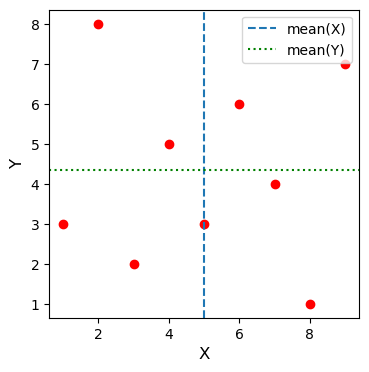

In [10]:
plt.figure(figsize=(4, 4))

plt.scatter(X, Y, color='r')

plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.axvline(data["X"].mean(), linestyle='--', label="mean(X)")
plt.axhline(data["Y"].mean(), linestyle=':', label="mean(Y)", color='green')
plt.legend();

### Covariance

Covariance is a numerical measure that captures the tendency of two variables to vary together. It builds directly on the idea of deviations from the mean. For each observation $i$, we compute the product of deviations $(X_i-\overline{X})(Y_i-\overline{Y})$. This product is positive when both variables are either above their means or below their means (i.e., they move together), and negative when one variable is above its mean while the other is below (i.e., they move in opposite directions). By examining these products across all observations, we can assess whether there is an overall pattern of joint movement.

To quantify this tendency, we sum the products of deviations and take their average, resulting in the covariance:

$$
Cov(X, Y) = \frac{1}{n-1}\sum_{i=1}^{n}{\left(X_i-\overline{X}\right)\left(Y_i-\overline{Y}\right)}.
$$
A positive covariance indicates that the variables tend to increase and decrease together, while a negative covariance indicates an inverse relationship. A covariance near zero suggests little to no linear association. From a geometric perspective, covariance can also be interpreted as the dot product of the deviation vectors (after centering the data), scaled by their length. This means it is maximized when the two vectors point in the same direction, zero when they are orthogonal (uncorrelated), and negative when they point in opposite directions.

### Pearson's Correlation Coefficient

While covariance provides a useful measure of how two variables vary together, it is not often reported on its own because its value depends on the units of the variables. For example, if $X$ is measured in inches and $Y$ in pounds, the covariance will be expressed in “inch-pounds,” which is not easy to interpret or compare across datasets. To address this issue, we standardize the deviations by dividing each by its standard deviation, producing *standard scores*. For each observation, we compute

$$
r_i = \frac{(X_i-\overline{X})}{\hat\sigma_X}\cdot\frac{(Y_i-\overline{Y})}{\hat\sigma_Y},
$$

which represents the product of how far each variable is from its mean in standardized units.

**Pearson’s Correlation Coefficient $R$** is then defined as the average of these standardized products. Equivalently, it can be written as the covariance divided by the product of the standard deviations:

$$
R = \frac{1}{n-1}\sum_{i=1}^{n}{r_i} = \frac{Cov(X, Y)}{\hat\sigma_X \cdot \hat\sigma_Y}.
$$

This formulation removes the issue of units and ensures that $R$ always lies between −1 and 1. A value close to 1 indicates a strong positive linear relationship, a value close to −1 indicates a strong negative linear relationship, and a value near 0 indicates little to no linear association.

Computationally, Pearson’s correlation coefficient can also be expressed directly in terms of deviations from the mean:

$$
R = \frac{\sum_{i=1}^{n}{(X_i-\overline{X})(Y_i-\overline{Y})}}{\sqrt{\sum_{i=1}^n{(X_i-\overline{X})^2}} \sqrt{\sum_{i=1}^n{(Y_i-\overline{Y})^2}}}
$$

This formula highlights how correlation depends on the alignment of deviations. When the correlation is positive, deviations of $X$ from its mean tend to correspond to deviations of $Y$ in the same direction. When the correlation is negative, deviations in $X$ correspond to deviations in $Y$ in the opposite direction. If there is no correlation, positive and negative contributions cancel each other out, causing the overall value of $R$ to approach zero.

In essence, Pearson’s correlation coefficient measures how “in sync” two variables are. For two variables to be strongly correlated, observations that are far above (or below) the mean in one variable should also be far above (or below) the mean in the other. When this consistent pattern breaks — such as when one variable is above its mean while the other is below — these opposing contributions offset each other, leading to a weak or nonexistent correlation.

### Pearson's Correlation Coefficient: Examples

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png">

<center>https://en.wikipedia.org/wiki/Correlation</center>

### $R^2$ and the Explained Variance

The **coefficient of determination**, denoted $R^2$, is simply the square of Pearson’s correlation coefficient $R$. While $R$ measures the strength and direction of a linear relationship, $R^2$ has a different and often more practical interpretation: it represents the proportion of variance in one variable that can be explained by the other. Because it is a squared value, $R^2$ always ranges from 0 to 1, regardless of whether the original correlation was positive or negative.

This distinction is important. For example, if $R = 0.8$, this indicates a strong positive linear relationship, but $R^2 = 0.64$. This means that **64% of the variability** in one variable can be explained by its linear relationship with the other, while the remaining 36% is due to other factors or random variation. Thus, $R^2$ provides a clearer sense of how much predictive power one variable has over another.

For example, consider the example of the relationship between the number of hotel rooms sold in Waikiki and average daily sales at ABC stores in the same area.

In [11]:
daily_sales = pd.read_table("data/room_abc_sales.tsv", header=None)
daily_sales

,0,1
0,180,66649.07
1,181,71557.20
2,182,104553.23
3,183,146851.52
4,184,84260.95
...,...,...
2815,2995,153410.75
2816,2996,170248.67
2817,2997,158253.04
2818,2998,182130.50


In [12]:
print(daily_sales[1].mean())

120227.70596808512


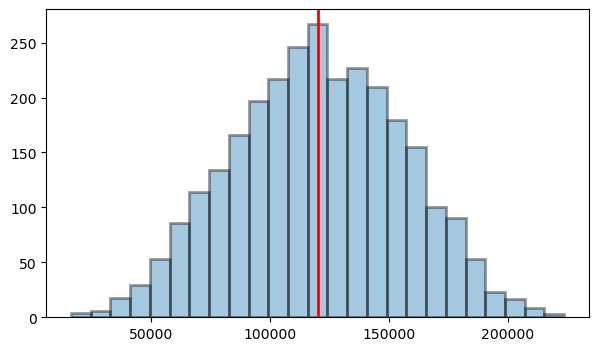

In [13]:
plt.figure(figsize=(7, 4))

plt.hist(daily_sales[1], bins=25, edgecolor="k", linewidth=2, alpha=0.4)
plt.axvline(daily_sales[1].mean(), color='r', linewidth=2);

In the absence of any additional information about ABC store sales, the most reasonable prediction for next Tuesday’s sales is simply the mean of the distribution, which is $\mu=\$120,228$. This is because the sales are assumed to follow a normal distribution, and without any other predictive variables, the mean minimizes overall prediction error. In other words, it is the best “baseline” estimate we can make when we know nothing else about the conditions affecting that particular day.

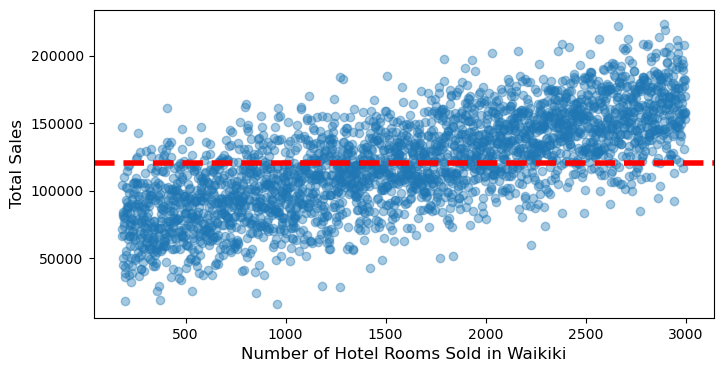

In [14]:
plt.figure(figsize=(8, 4))

plt.scatter(daily_sales[0], daily_sales[1], alpha=0.4)
plt.xlabel("Number of Hotel Rooms Sold in Waikiki", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.axhline(np.mean(daily_sales[1]), color='r', linestyle='--', linewidth=4);

However, this baseline raises an important question: *good compared to what?* The mean is only the best predictor when no other relevant information is available. In practice, we often have access to additional variables that may be correlated with sales, such as the number of hotel rooms sold in Waikiki, the presence of special events, or whether the day falls on a holiday. If any of these variables are strongly correlated with sales, they can significantly improve our predictions beyond simply using the average.

This is where the concept of a **regression line** becomes important. When we incorporate a correlated variable — such as hotel occupancy — the relationship between that variable and daily sales can be modeled using a line that best fits the observed data. This line, known as the regression line, represents the model that explains how sales change as the predictor variable changes. Instead of always predicting the same mean value, the regression model allows us to adjust our prediction based on current conditions (e.g., higher hotel occupancy leading to higher expected sales), resulting in more accurate and informative forecasts.

<center><img src="https://www.dropbox.com/scl/fi/zsknqmfsdqmvuv6rkqfp1/reg.png?rlkey=b5tfw5g3oq081n8qzlqjjmnhv&st=xrt8p37h&dl=1" alt="drawing" width="700"></center>

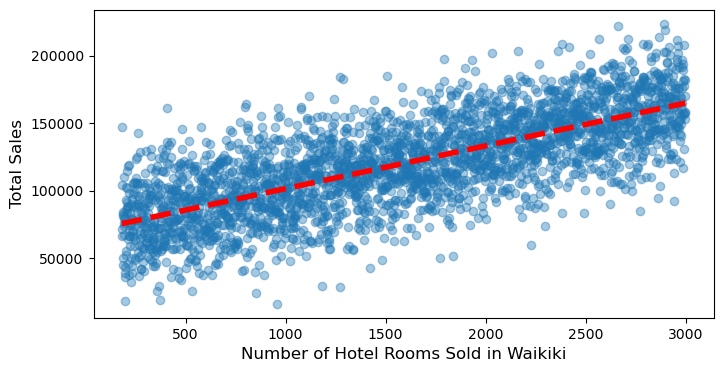

In [16]:
plt.figure(figsize=(8, 4))

plt.scatter(daily_sales[0], daily_sales[1], alpha=0.4)
plt.plot(daily_sales[0], 69843.88 + 31.69 * daily_sales[0], color='r', linewidth=4, linestyle='--')

plt.xlabel("Number of Hotel Rooms Sold in Waikiki", fontsize=12)
plt.ylabel("Total Sales", fontsize=12);

### Residuals and Variance Explained

Residuals are central to understanding how well a regression model performs. A **residual** is the difference between an observed value and the value predicted by the regression line. In other words, it represents the error made by the model for each data point. If the regression line predicts a value very close to the observed one, the residual is small; if the prediction is far off, the residual is large. By examining these residuals, we can assess how well our model captures the underlying relationship in the data.

<center><img src="https://www.dropbox.com/scl/fi/06oievjhg3fdfp5bu0etm/residuals.png?rlkey=4wxze71e9yh11nxmghlirrbhg&st=51mhgrwp&dl=1" alt="drawing" width="400"/><br><br>

When building a predictive model, our goal is to minimize these residuals. The regression line is specifically chosen to achieve this by minimizing the overall discrepancy between predicted and observed values — typically by minimizing the sum of squared residuals. This ensures that the fitted line lies as close as possible to the data points. If we were to use the mean as our predictor instead, we would ignore any relationship between variables and end up with larger overall errors. The regression line improves upon this by adapting predictions based on the explanatory variable, thereby reducing the total residual variation.

<center><img src="https://www.dropbox.com/scl/fi/vwlln4rqfy4gsnz0w1doq/mean_vs_reg_residuals.png?rlkey=cmmz19tf7mxu1swpyrn8i4gi6&st=vetag13c&dl=1" alt="drawing" style="width:800px"/>
<center>Mean vs. Regression Residuals</center><br><br>

This leads directly to the concept of **variance explained**. The total variability in the data can be thought of as the variance around the mean, while the regression line reduces this variability by accounting for patterns in the data. The coefficient of determination, $R^2$, quantifies how much of this variance is explained by the regression model. It compares the variance of residuals from the regression line ($\sigma^2_{red\_line}$) to the variance around the mean ($\sigma^2_{mean\_line}$), normalized so that the value lies between 0 and 1. Because the regression line is optimized to fit the data, its residual variance will always be less than or equal to the variance around the mean.

<center><img src="https://www.dropbox.com/scl/fi/7pz4uq1xxx0gxtg5jvjrv/mean_vs_reg_residuals_2.png?rlkey=52sjavkreldkg9l4jxt0tq4dm&st=xl7dk41f&dl=1" alt="drawing" style="width:800px"/></center>

In [17]:
from scipy import stats

print(stats.pearsonr(daily_sales[0], daily_sales[1]))
print(stats.pearsonr(daily_sales[0], daily_sales[1])[0] ** 2)

PearsonRResult(statistic=np.float64(0.7262702431699775), pvalue=np.float64(0.0))
0.5274684661141782


In [18]:
var_mean = np.sum((daily_sales[1] - np.mean(daily_sales[1]))**2)
print(var_mean)

3559841164665.26


In [19]:
predicted_val = 69843.88 + 31.69 * np.array(daily_sales[0])
var_red_line = np.sum((daily_sales[1] - predicted_val)**2)
print(var_red_line)

1682137768328.9448


In [20]:
print((var_mean - var_red_line) / var_mean)

0.5274683081296634


In the Waikiki example, the correlation between hotel rooms sold and ABC Store sales is $R = 0.726$, which gives $R^2 = 0.527$. This means that approximately $53\%$ of the variation in daily sales can be explained by hotel occupancy alone. While this indicates a meaningful relationship, it also shows that nearly half of the variation is due to other factors. Still, using hotel room occupancy as a predictor is clearly more informative than simply using the mean.

Finally, the magnitude of $R^2$ helps us evaluate the usefulness of a predictor in a *linear model*. A low $R^2$ suggests that the variable $X$ does not explain much of the variation in $Y$, though it does not rule out more complex (nonlinear) relationships. In real-world scenarios, outcomes are often influenced by multiple factors. For example, ABC Store sales may also depend on weather conditions, local events, or holidays. Incorporating additional explanatory variables — such as rainfall or major events in Waikiki — can further reduce residuals and improve the model’s predictive power. This naturally leads to more advanced approaches like multiple linear regression, where several variables are used together to explain variation in the response.

### Spearman's Rank Correlation

Spearman’s rank correlation extends the idea of correlation by working with the ranks of the data rather than their raw values. For each observation $x_i$ and $y_i$, we assign ranks $rank_{x_i}$ and $rank_{y_i}$, which represent their positions when the data are sorted. These ranks range from 1 to $n$, where $n$ is the number of observations. By replacing values with ranks, the method focuses purely on the ordering of the data rather than the magnitude of differences between values.

Unlike Pearson’s correlation, which measures how well data fits a straight line, Spearman’s correlation evaluates how consistent the ordering is between two variables. It effectively counts how many pairs are “disordered,” meaning cases where the relative ordering between $X$ and $Y$ does not match. If the rankings are very similar, the correlation is high and positive; if one ranking is the reverse of the other, the correlation is strongly negative.

The Spearman correlation coefficient $\rho$ can be computed using the formula:

$$
 \large
 \rho = 1 - \frac{6 \sum(rank_{x_i} - rank_{y_i})^2}{n (n^2 -1)}
$$

This formula shows that the correlation depends on the squared differences between the ranks of corresponding observations. When the ranks are identical, all differences are zero and $\rho=1$, indicating perfect agreement. As the differences grow, $\rho$ decreases.

Because it relies on ranks, Spearman’s correlation is more robust to skewed distributions and outliers than Pearson’s correlation. Extreme values may greatly affect numerical differences, but they have much less impact on rank positions. As a result, Spearman’s method is especially useful when the relationship between variables is monotonic but not linear, or when the data violate the assumptions required for Pearson’s correlation.

<center><img src="https://www.dropbox.com/scl/fi/tx32fl8n9am8o7imfqs8w/spearman.png?rlkey=i9mukd5vuz592cclk8pckqv4t&st=l83k3wdr&dl=1"/></center>

### Correlation and Causation

It is important to remember that correlation does not imply causation. Just because two variables move together, either positively or negatively, it does not mean that one variable causes the other to change. Correlation simply quantifies the degree to which two variables are associated—it does not provide evidence about underlying mechanisms or causal relationships.

For example, the number of policemen active in a precinct may be strongly correlated with the local crime rate. However, this does not mean that the presence of police causes crime. In reality, higher crime rates often lead to more police being deployed, and other underlying factors may affect both variables.

Another illustrative example involves university Master’s degrees and total box office revenue per year. Over time, both variables may increase, resulting in a high correlation. However, the correlation is not causal — both trends are influenced by the growing global population. A larger population leads to more Master’s degrees being awarded and more people attending movies, creating a spurious correlation between the two variables.

These examples highlight why careful interpretation is critical: correlations can reveal patterns and potential relationships, but they cannot, by themselves, prove that changes in one variable cause changes in another. Understanding causation usually requires experimental design, controlled studies, or additional domain knowledge.

For more examples and discussion, see [Statology: Correlation Does Not Imply Causation](https://www.statology.org/correlation-does-not-imply-causation-examples/).

## Statistical Significance
  
In statistics, significance is about determining whether an observed pattern or relationship in the data is likely to be real, or if it could have arisen purely by chance. Data miners may focus on whether observations are interesting or unusual, but statisticians are concerned with whether these observations are statistically significant. A result is generally considered statistically significant if the probability of observing it by random chance is very low — commonly less than 5% (p-value < 0.05).

When it comes to correlations, statistical significance helps us determine whether the measured correlation between two variables could plausibly occur just by chance. This significance depends on two factors: the sample size and the true underlying correlation. With very few data points, even a perfect correlation ($R$ = 1 or -1) may not be meaningful, because small datasets are more susceptible to random fluctuations. Conversely, in a large dataset, even a moderate correlation is less likely to appear purely by chance, making it more likely to be meaningful.

One practical way to assess significance is bootstrapping, which we have already discussed. By repeatedly resampling the dataset, we can generate a “background distribution” of correlation coefficients that might occur purely by chance. Comparing the observed correlation to this distribution allows us to see how unusual it is: if the observed correlation lies far in the tails of the bootstrap-generated distribution, it is considered statistically significant. This approach provides a flexible, assumption-free method to evaluate whether a measured correlation likely reflects a real relationship rather than random variation.

In [36]:
def simulate_corr(n=10, nb_repeats=1000, p=1/20):
    corr_ = []
    
    for _ in range(nb_repeats):
        x = np.random.randint(0, 100, n)
        y = np.random.randint(0, 100, n)
        corr_.append(np.abs(stats.pearsonr(x, y)[0]))
    return (np.quantile(corr_, 1-p), max(corr_))

In [37]:
simulate_corr(n=10, nb_repeats=100000, p=1/20)

(np.float64(0.6358352742875777), np.float64(0.964490979843727))

In [38]:
sample_size = np.arange(10, 1010, 10)
max_common_corr = []
max_corr = []

for n in sample_size:
    max_c_r, max_r = simulate_corr(n, nb_repeats=10000)
    max_common_corr.append(max_c_r)
    max_corr.append(max_r)

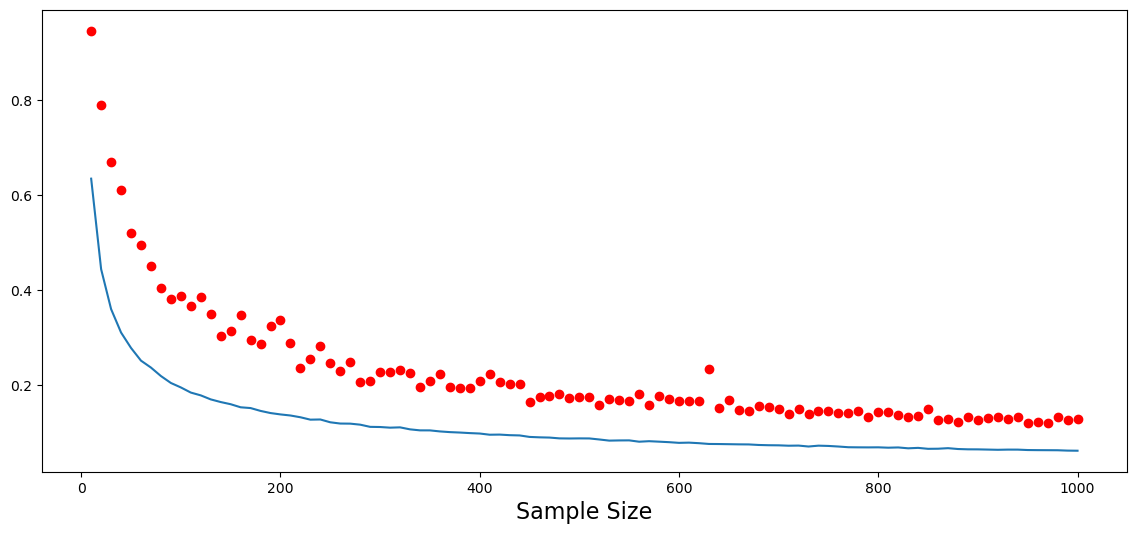

In [45]:
plt.figure(figsize=(14, 6))
plt.plot(sample_size, max_common_corr)
plt.scatter(sample_size, max_corr, color="red")
plt.xlabel("Sample Size", fontsize=16);